# Интерпретация ИИ-моделей на гетерогенных данных

## Условие

Реализовать интерпретацию предсказаний модели машинного обучения, работающей с гетерогенными данными: табличными признаками и текстовыми эмбеддингами.

Данные должны быть синтетическими. Целевая переменная должна имитироваться как функция от выбранных информативных признаков с добавлением шума. Задача решается как бинарная классификация с использованием классического ансамблевого метода, например случайного леса или градиентного бустинга.

Необходимо:

- обучить модель на объединенном пространстве табличных признаков и текстовых эмбеддингов;
- выполнить локальную интерпретацию отдельных предсказаний с помощью LIME;
- выполнить локальную и глобальную интерпретацию модели с помощью SHAP;
- сгруппировать вклады признаков по модальностям;
- сравнить важность отдельных признаков и важность табличной/текстовой модальности.

Ожидаемый результат: синтетический датасет, обученная модель бинарной классификации, метрики качества, LIME- и SHAP-интерпретации, оценка вклада каждой модальности и выводы.

## Описание реализации

В ноутбуке реализована лабораторная работа по интерпретации модели бинарной классификации, которая использует две модальности данных:

- табличные числовые признаки;
- текстовые эмбеддинги фиксированной размерности.

Для анализа используются локальные объяснения LIME, локальные и глобальные объяснения SHAP, а также агрегация вкладов признаков по модальностям.

## Подготовка окружения

Если необходимые библиотеки еще не установлены, выполните ячейку ниже. После установки лучше перезапустить kernel и выполнить ноутбук сверху вниз.

In [1]:
# Раскомментируйте строку при первом запуске ноутбука.
# %pip install -r requirements.txt

In [2]:
import importlib
import re
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "lime": "lime",
    "shap": "shap",
}

missing_packages = [package_name for import_name, package_name in required_packages.items() if importlib.util.find_spec(import_name) is None]
if missing_packages:
    raise ImportError(
        "Не установлены зависимости: "
        + ", ".join(missing_packages)
        + ". Выполните `%pip install -r requirements.txt` и перезапустите kernel."
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

/data/Labs_maga/Methods_for_processing_and_analysing_heterogeneous_data/.conda/envs/env-labs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Генерация синтетических гетерогенных данных

Целевая переменная формируется из нескольких информативных табличных признаков и координат текстового эмбеддинга. Остальные признаки добавлены как шумовые. Это позволяет сравнить найденные LIME/SHAP важности с известной логикой генерации данных.

In [3]:
n_samples = 2_500
embedding_dim = 24

# Табличная модальность: 4 информативных и 4 шумовых признака.
tabular_features = [
    "tab_signal_positive",
    "tab_signal_negative",
    "tab_interaction",
    "tab_threshold",
    "tab_noise_0",
    "tab_noise_1",
    "tab_noise_2",
    "tab_noise_3",
]
text_embedding_features = [f"emb_{i}" for i in range(embedding_dim)]
all_features = tabular_features + text_embedding_features

X_tabular = rng.normal(loc=0.0, scale=1.0, size=(n_samples, len(tabular_features)))
X_embedding = rng.normal(loc=0.0, scale=1.0, size=(n_samples, embedding_dim))

X = pd.DataFrame(np.hstack([X_tabular, X_embedding]), columns=all_features)

linear_signal = (
    1.45 * X["tab_signal_positive"]
    - 1.20 * X["tab_signal_negative"]
    + 0.85 * X["tab_interaction"]
    + 0.70 * (X["tab_threshold"] > 0.25).astype(float)
    + 1.10 * X["emb_2"]
    - 0.95 * X["emb_7"]
    + 0.75 * X["emb_11"]
    + 0.45 * X["tab_signal_positive"] * X["emb_2"]
)
noise = rng.normal(loc=0.0, scale=0.85, size=n_samples)
logits = linear_signal + noise
probability = 1 / (1 + np.exp(-logits))
y = pd.Series(rng.binomial(n=1, p=probability), name="target")

true_signal_description = pd.DataFrame(
    [
        ("tab_signal_positive", "tabular", "+", 1.45),
        ("tab_signal_negative", "tabular", "-", -1.20),
        ("tab_interaction", "tabular", "+", 0.85),
        ("tab_threshold", "tabular", "+ при значении > 0.25", 0.70),
        ("emb_2", "text_embedding", "+", 1.10),
        ("emb_7", "text_embedding", "-", -0.95),
        ("emb_11", "text_embedding", "+", 0.75),
        ("tab_signal_positive * emb_2", "cross_modal", "+", 0.45),
    ],
    columns=["feature", "modality", "expected_effect", "coefficient"],
)

print(f"Dataset shape: {X.shape}")
print(f"Positive class share: {y.mean():.3f}")
display(X.head())
display(true_signal_description)

Dataset shape: (2500, 32)
Positive class share: 0.522


,tab_signal_positive,tab_signal_negative,tab_interaction,tab_threshold,tab_noise_0,tab_noise_1,tab_noise_2,tab_noise_3,emb_0,emb_1,...,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-1.658201,0.891207,...,0.459561,0.742249,-1.061035,-1.227302,0.795822,-0.282352,1.173621,0.143133,3.556363,-0.472320
1,-0.016801,-0.853044,0.879398,0.777792,0.066031,1.127241,0.467509,-0.859292,0.389132,-0.794146,...,-1.232162,-0.839697,-0.223699,1.304624,1.119765,0.819766,-0.039160,1.229570,-0.052645,0.677968
2,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,1.012039,1.796820,...,0.221864,0.266470,-0.480388,2.033464,0.429761,1.128489,-1.456213,-1.464842,0.460063,1.854858
3,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-1.009936,0.143377,...,0.706779,0.007294,-0.156829,-0.649115,0.192162,1.617248,1.137857,-0.256210,0.538621,-1.101430
4,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,0.730067,-0.830857,...,-0.008721,0.345899,1.773611,-1.127971,0.644630,-0.072898,-0.499045,1.072174,-1.461426,-2.366433


,feature,modality,expected_effect,coefficient
0,tab_signal_positive,tabular,+,1.45
1,tab_signal_negative,tabular,-,-1.20
2,tab_interaction,tabular,+,0.85
3,tab_threshold,tabular,+ при значении > 0.25,0.70
4,emb_2,text_embedding,+,1.10
5,emb_7,text_embedding,-,-0.95
6,emb_11,text_embedding,+,0.75
7,tab_signal_positive * emb_2,cross_modal,+,0.45


## Обучение модели

Используем градиентный бустинг: это ансамблевый метод, который хорошо работает с нелинейностями и поддерживается `shap.TreeExplainer`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = GradientBoostingClassifier(
    n_estimators=220,
    learning_rate=0.045,
    max_depth=3,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
        ],
    }
)

display(metrics.style.format({"value": "{:.3f}"}))
print(classification_report(y_test, y_pred, target_names=["class_0", "class_1"]))

,metric,value
0,accuracy,0.752
1,precision,0.770
2,recall,0.748
3,f1,0.759
4,roc_auc,0.846


              precision    recall  f1-score   support

     class_0       0.73      0.76      0.74       299
     class_1       0.77      0.75      0.76       326

    accuracy                           0.75       625
   macro avg       0.75      0.75      0.75       625
weighted avg       0.75      0.75      0.75       625



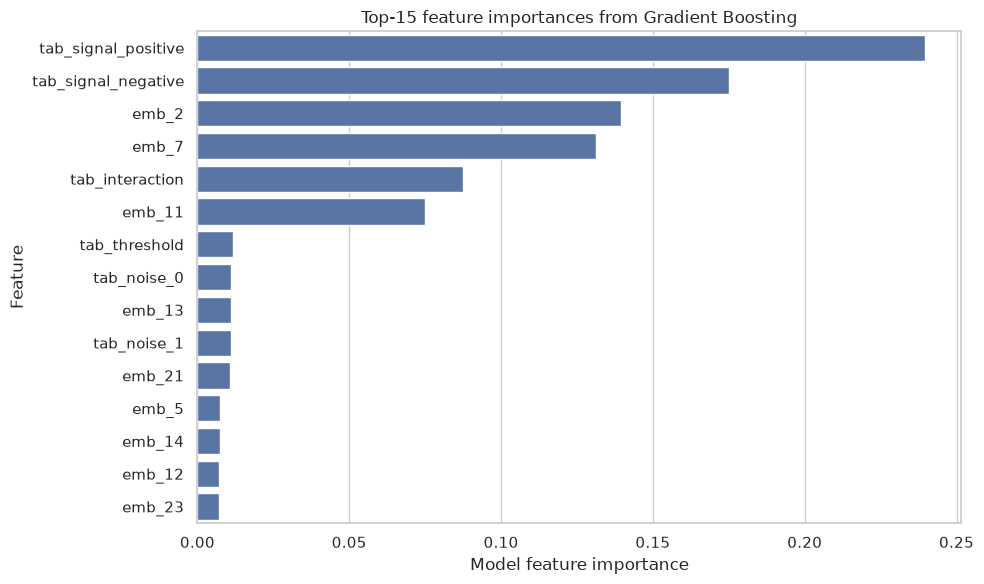

,feature,importance
0,tab_signal_positive,0.239583
1,tab_signal_negative,0.175217
2,emb_2,0.139475
3,emb_7,0.131170
4,tab_interaction,0.087530
5,emb_11,0.074785
6,tab_threshold,0.011735
7,tab_noise_0,0.011086
8,emb_13,0.011060
9,tab_noise_1,0.010924


In [5]:
model_importance = (
    pd.DataFrame({"feature": all_features, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=model_importance.head(15), x="importance", y="feature", color="#4C72B0")
plt.title("Top-15 feature importances from Gradient Boosting")
plt.xlabel("Model feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(model_importance.head(15))

## Локальная интерпретация с LIME

Для локального анализа выберем три объекта:

- уверенный положительный класс;
- уверенный отрицательный класс;
- объект около границы решения.

In [6]:
selected_positions = {
    "confident_positive": int(np.argmax(y_proba)),
    "confident_negative": int(np.argmin(y_proba)),
    "decision_boundary": int(np.argmin(np.abs(y_proba - 0.5))),
}

selected_objects = pd.DataFrame(
    {
        "case": list(selected_positions.keys()),
        "test_position": list(selected_positions.values()),
        "true_target": [int(y_test.iloc[position]) for position in selected_positions.values()],
        "predicted_probability_class_1": [float(y_proba[position]) for position in selected_positions.values()],
    }
)
display(selected_objects)

,case,test_position,true_target,predicted_probability_class_1
0,confident_positive,623,1,0.989329
1,confident_negative,286,0,0.017823
2,decision_boundary,235,1,0.501159


confident_positive: probability(class_1) = 0.989, true target = 1


/data/Labs_maga/Methods_for_processing_and_analysing_heterogeneous_data/.conda/envs/env-labs/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


,feature_condition,lime_weight_for_class_1
0,tab_signal_positive > 0.64,0.291494
1,tab_signal_negative <= -0.66,0.191385
2,emb_7 <= -0.68,0.166760
3,emb_2 > 0.63,0.164819
4,emb_11 > 0.67,0.130163
5,tab_interaction > 0.71,0.117366
6,tab_threshold <= -0.70,-0.036789
7,-0.05 < emb_4 <= 0.64,0.019394
8,-0.68 < emb_5 <= -0.01,-0.019339
9,emb_17 <= -0.69,0.013523


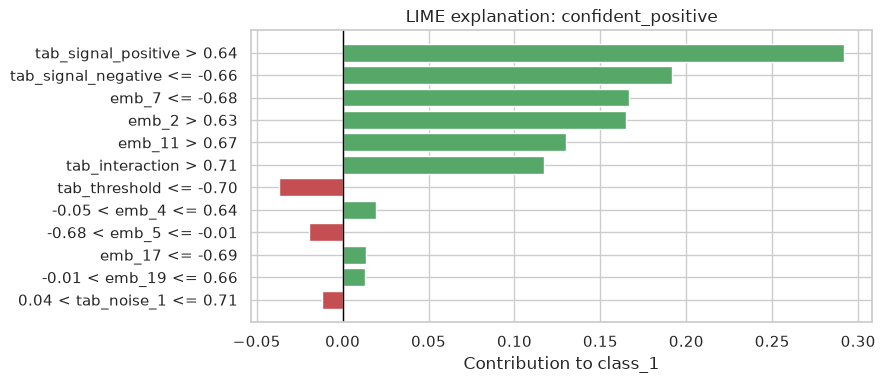

confident_negative: probability(class_1) = 0.018, true target = 0


/data/Labs_maga/Methods_for_processing_and_analysing_heterogeneous_data/.conda/envs/env-labs/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


,feature_condition,lime_weight_for_class_1
0,tab_signal_negative > 0.68,-0.203939
1,emb_2 <= -0.67,-0.199676
2,emb_7 > 0.71,-0.188029
3,0.01 < tab_interaction <= 0.71,0.069483
4,-0.01 < tab_signal_positive <= 0.64,0.067133
5,0.02 < emb_11 <= 0.67,0.041428
6,tab_noise_1 > 0.71,-0.035066
7,-0.70 < tab_threshold <= -0.05,-0.030828
8,emb_13 > 0.64,-0.030727
9,0.02 < emb_12 <= 0.69,-0.025947


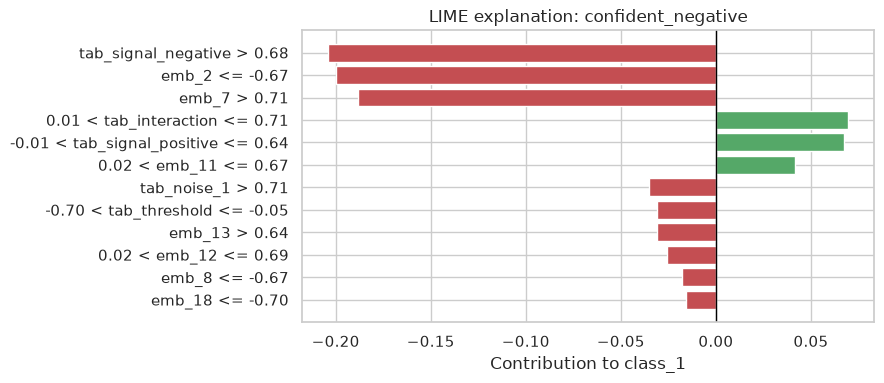

/data/Labs_maga/Methods_for_processing_and_analysing_heterogeneous_data/.conda/envs/env-labs/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


decision_boundary: probability(class_1) = 0.501, true target = 1


,feature_condition,lime_weight_for_class_1
0,tab_signal_negative > 0.68,-0.197013
1,emb_11 > 0.67,0.110977
2,-0.68 < tab_signal_positive <= -0.01,-0.057721
3,-0.68 < emb_7 <= 0.01,0.050757
4,-0.67 < emb_2 <= -0.04,-0.048239
5,0.01 < tab_interaction <= 0.71,0.039852
6,tab_noise_0 > 0.62,-0.030322
7,emb_9 > 0.61,-0.028556
8,emb_6 > 0.67,0.020918
9,-0.57 < emb_21 <= 0.06,0.019965


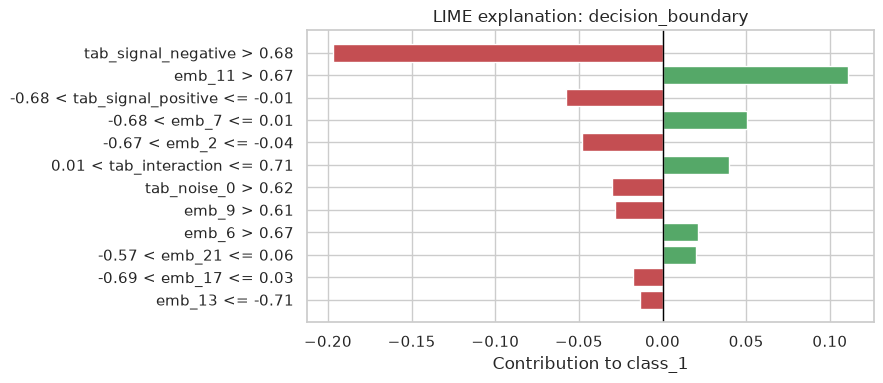

In [7]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=all_features,
    class_names=["class_0", "class_1"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

def explain_with_lime(position: int, num_features: int = 12) -> pd.DataFrame:
    explanation = lime_explainer.explain_instance(
        data_row=X_test.iloc[position].to_numpy(),
        predict_fn=model.predict_proba,
        num_features=num_features,
        labels=(1,),
    )
    explanation_df = pd.DataFrame(
        explanation.as_list(label=1),
        columns=["feature_condition", "lime_weight_for_class_1"],
    )
    return explanation_df

lime_explanations = {}
for case_name, position in selected_positions.items():
    lime_explanations[case_name] = explain_with_lime(position)
    print(f"{case_name}: probability(class_1) = {y_proba[position]:.3f}, true target = {int(y_test.iloc[position])}")
    display(lime_explanations[case_name])

    plt.figure(figsize=(9, 4))
    plot_data = lime_explanations[case_name].iloc[::-1]
    colors = np.where(plot_data["lime_weight_for_class_1"] >= 0, "#55A868", "#C44E52")
    plt.barh(plot_data["feature_condition"], plot_data["lime_weight_for_class_1"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"LIME explanation: {case_name}")
    plt.xlabel("Contribution to class_1")
    plt.tight_layout()
    plt.show()

## Интерпретация с SHAP

SHAP-значения показывают вклад каждого признака в сдвиг предсказания относительно базового значения модели. Для глобального анализа используем среднее абсолютное SHAP-значение по тестовой выборке.

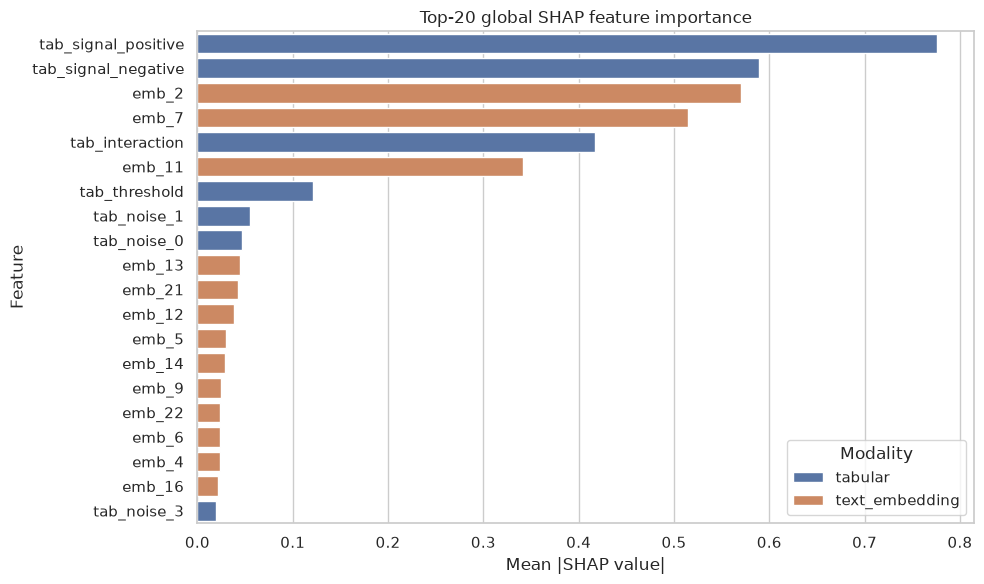

,feature,mean_abs_shap,modality
0,tab_signal_positive,0.775941,tabular
1,tab_signal_negative,0.589684,tabular
10,emb_2,0.570572,text_embedding
15,emb_7,0.514298,text_embedding
2,tab_interaction,0.417324,tabular
19,emb_11,0.341492,text_embedding
3,tab_threshold,0.121722,tabular
5,tab_noise_1,0.055193,tabular
4,tab_noise_0,0.046770,tabular
21,emb_13,0.045104,text_embedding


In [8]:
shap_explainer = shap.TreeExplainer(model)
raw_shap_values = shap_explainer.shap_values(X_test)

if isinstance(raw_shap_values, list):
    shap_values_class_1 = raw_shap_values[1]
else:
    raw_shap_values = np.asarray(raw_shap_values)
    if raw_shap_values.ndim == 3:
        class_axis = 2 if raw_shap_values.shape[2] <= 3 else 0
        shap_values_class_1 = raw_shap_values[:, :, 1] if class_axis == 2 else raw_shap_values[1]
    else:
        shap_values_class_1 = raw_shap_values

expected_value = shap_explainer.expected_value
if isinstance(expected_value, (list, tuple, np.ndarray)):
    expected_value_class_1 = np.asarray(expected_value).reshape(-1)[-1]
else:
    expected_value_class_1 = expected_value

shap_importance = pd.DataFrame(
    {
        "feature": all_features,
        "mean_abs_shap": np.abs(shap_values_class_1).mean(axis=0),
        "modality": ["tabular" if feature in tabular_features else "text_embedding" for feature in all_features],
    }
).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_importance.head(20), x="mean_abs_shap", y="feature", hue="modality", dodge=False)
plt.title("Top-20 global SHAP feature importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.legend(title="Modality")
plt.tight_layout()
plt.show()

display(shap_importance.head(20))

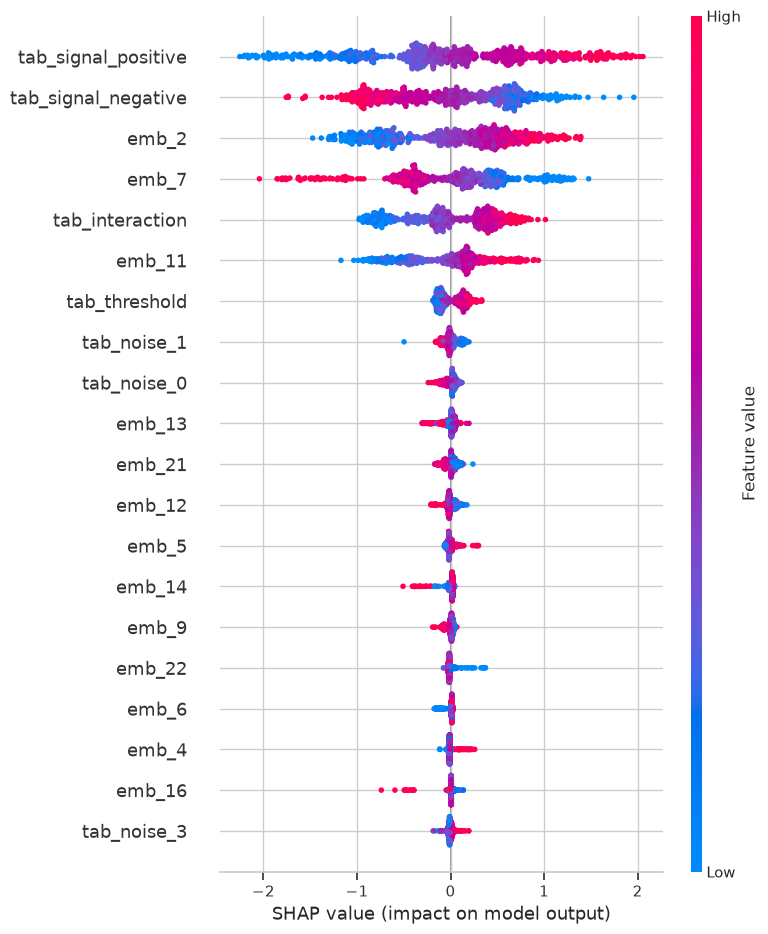

In [9]:
shap.summary_plot(
    shap_values_class_1,
    X_test,
    feature_names=all_features,
    max_display=20,
    show=True,
)

confident_positive: probability(class_1) = 0.989, true target = 1


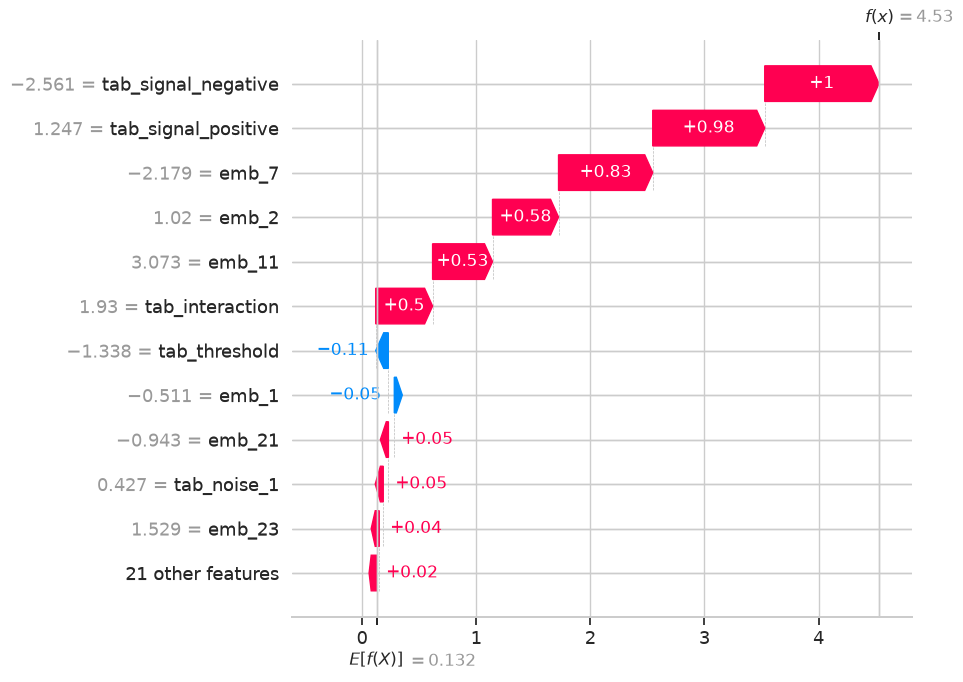

confident_negative: probability(class_1) = 0.018, true target = 0


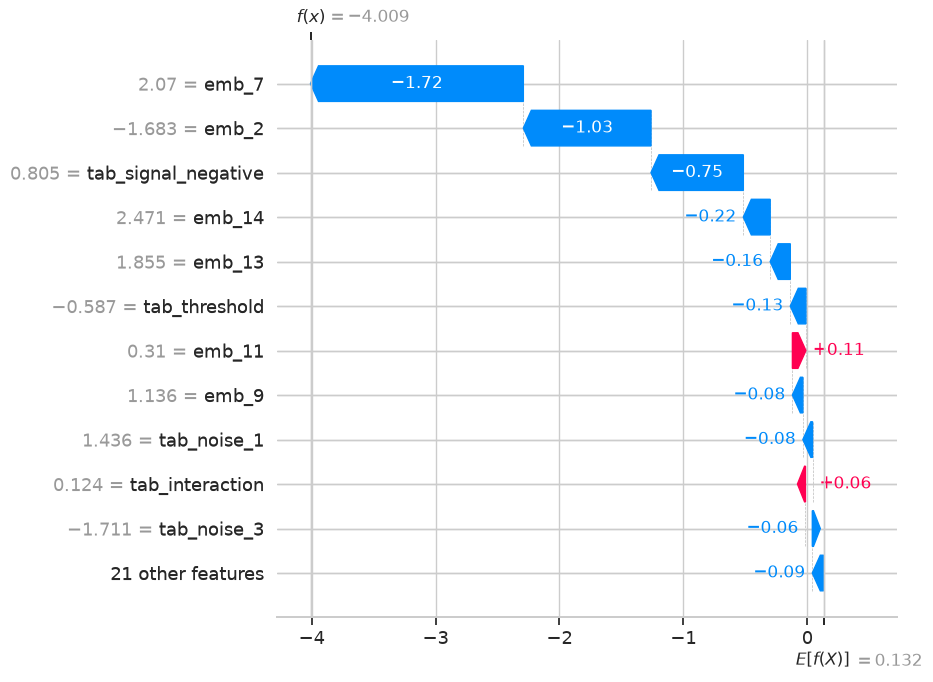

decision_boundary: probability(class_1) = 0.501, true target = 1


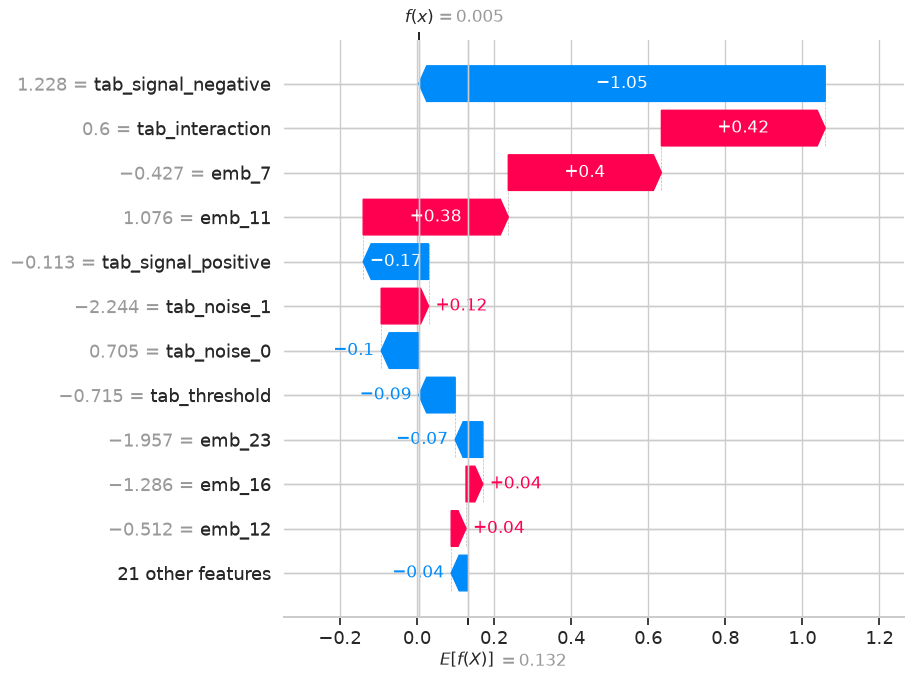

In [10]:
for case_name, position in selected_positions.items():
    explanation = shap.Explanation(
        values=shap_values_class_1[position],
        base_values=expected_value_class_1,
        data=X_test.iloc[position].to_numpy(),
        feature_names=all_features,
    )
    print(f"{case_name}: probability(class_1) = {y_proba[position]:.3f}, true target = {int(y_test.iloc[position])}")
    shap.plots.waterfall(explanation, max_display=12, show=True)

## Агрегация вкладов по модальностям

Чтобы оценить вклад каждой модальности, сгруппируем абсолютные значения вкладов признаков внутри групп `tabular` и `text_embedding`. Для SHAP это делается по всей тестовой выборке, для LIME — по выбранным локальным объяснениям.

,modality,mean_abs_shap_sum,relative_contribution
0,tabular,2.0386,52.2%
1,text_embedding,1.8668,47.8%


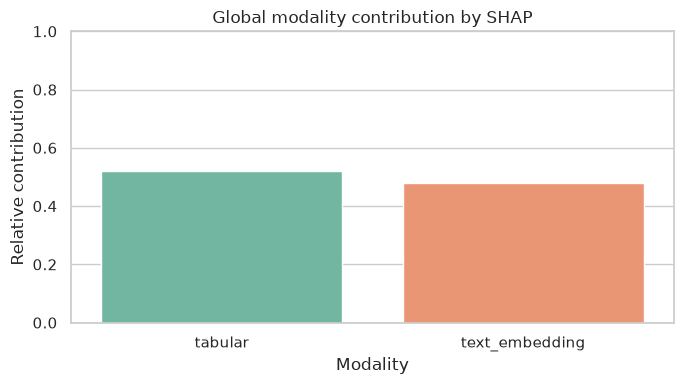

In [11]:
feature_to_modality = pd.Series(
    {feature: "tabular" for feature in tabular_features}
    | {feature: "text_embedding" for feature in text_embedding_features}
)

abs_shap = pd.DataFrame(np.abs(shap_values_class_1), columns=all_features, index=X_test.index)
local_shap_modality_contrib = abs_shap.T.groupby(feature_to_modality).sum().T

global_modality_contrib = (
    local_shap_modality_contrib.mean()
    .rename("mean_abs_shap_sum")
    .reset_index()
    .rename(columns={"index": "modality"})
)
global_modality_contrib["relative_contribution"] = (
    global_modality_contrib["mean_abs_shap_sum"] / global_modality_contrib["mean_abs_shap_sum"].sum()
)

display(global_modality_contrib.style.format({"mean_abs_shap_sum": "{:.4f}", "relative_contribution": "{:.1%}"}))

plt.figure(figsize=(7, 4))
sns.barplot(data=global_modality_contrib, x="modality", y="relative_contribution", palette="Set2")
plt.title("Global modality contribution by SHAP")
plt.xlabel("Modality")
plt.ylabel("Relative contribution")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

,case,modality,sum_abs_lime_weight,relative_contribution
0,confident_positive,tabular,0.6493,55.2%
1,confident_positive,text_embedding,0.5268,44.8%
2,confident_negative,tabular,0.4064,43.9%
3,confident_negative,text_embedding,0.5197,56.1%
4,decision_boundary,tabular,0.3249,51.2%
5,decision_boundary,text_embedding,0.3103,48.8%


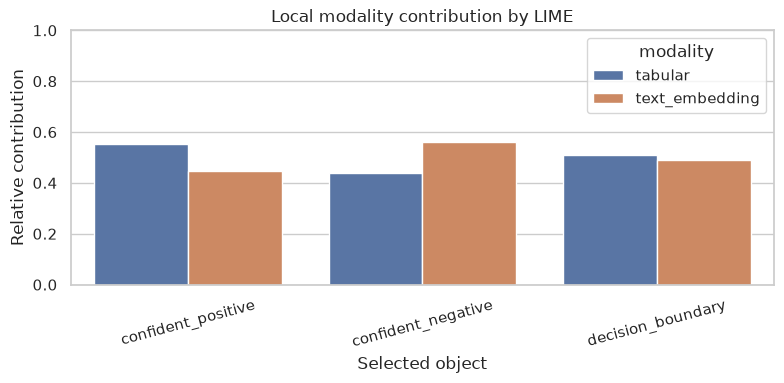

In [12]:
def extract_feature_name(lime_condition: str) -> str | None:
    for feature in sorted(all_features, key=len, reverse=True):
        pattern = rf"(?<![A-Za-z0-9_]){re.escape(feature)}(?![A-Za-z0-9_])"
        if re.search(pattern, lime_condition):
            return feature
    return None

def aggregate_lime_by_modality(explanation_df: pd.DataFrame) -> pd.DataFrame:
    result = explanation_df.copy()
    result["feature"] = result["feature_condition"].map(extract_feature_name)
    result["modality"] = result["feature"].map(feature_to_modality)
    result["abs_lime_weight"] = result["lime_weight_for_class_1"].abs()
    return (
        result.groupby("modality", dropna=False)["abs_lime_weight"]
        .sum()
        .rename("sum_abs_lime_weight")
        .reset_index()
        .assign(relative_contribution=lambda df: df["sum_abs_lime_weight"] / df["sum_abs_lime_weight"].sum())
    )

lime_modality_rows = []
for case_name, explanation_df in lime_explanations.items():
    modality_df = aggregate_lime_by_modality(explanation_df)
    modality_df.insert(0, "case", case_name)
    lime_modality_rows.append(modality_df)

lime_modality_contrib = pd.concat(lime_modality_rows, ignore_index=True)
display(lime_modality_contrib.style.format({"sum_abs_lime_weight": "{:.4f}", "relative_contribution": "{:.1%}"}))

plt.figure(figsize=(8, 4))
sns.barplot(data=lime_modality_contrib, x="case", y="relative_contribution", hue="modality")
plt.title("Local modality contribution by LIME")
plt.xlabel("Selected object")
plt.ylabel("Relative contribution")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Итоговые выводы

После выполнения ноутбука необходимо сопоставить полученные результаты с заданной функцией генерации данных:

- среди наиболее важных признаков должны появляться `tab_signal_positive`, `tab_signal_negative`, `tab_interaction`, `tab_threshold`, `emb_2`, `emb_7` и `emb_11`;
- SHAP дает устойчивую глобальную картину важности признаков и позволяет агрегировать вклад по модальностям на всей тестовой выборке;
- LIME полезен для локального объяснения отдельных объектов, но его веса зависят от выбранной точки и локального приближения;
- вклад табличной и текстовой модальности должен быть сопоставимым, потому что целевая переменная специально зависит от информативных признаков обеих групп;
- если одна из модальностей доминирует, это нужно интерпретировать через найденные важности признаков, качество модели и выбранный объект для локального анализа.